In [2]:
# ============================================
# HNG Data Analytics – Stage 2B Task
# Outlier Detection in Election Data (NIGER)
# ============================================

# STEP 0: Import libraries
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
import folium
from folium.plugins import MarkerCluster
from statistics import mean
import matplotlib.pyplot as plt
from openpyxl import Workbook

# --------------------------------------------
# STEP 1: Load Dataset (Already Has Coordinates)
# --------------------------------------------
df = pd.read_csv('NIGER_with_coordinates.csv')
print("Loaded dataset:", df.shape)
print(df.head())

# Identify your relevant columns
polling_unit_col = 'PU-Name'  # adjust if different
ward_col = 'Ward'                       # adjust if different
lga_col = 'LGA'                         # adjust if different
lat_col = 'Latitude'                    # adjust if different
lon_col = 'Longitude'                   # adjust if different

# Identify political party vote columns
vote_cols = ['APC', 'PDP', 'LP']  # update this list to match your dataset

# Clean numeric vote columns
df[vote_cols] = df[vote_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Ensure lat/lon columns are numeric
df[lat_col] = pd.to_numeric(df[lat_col], errors='coerce')
df[lon_col] = pd.to_numeric(df[lon_col], errors='coerce')
df = df.dropna(subset=[lat_col, lon_col])


Loaded dataset: (4394, 22)
   State    LGA  Ward       PU-Code   PU-Name  Accredited_Voters  \
0  NIGER  AGAIE  BARO  26-01-01-001    AKWANO                164   
1  NIGER  AGAIE  BARO  26-01-01-003   BARO II                148   
2  NIGER  AGAIE  BARO  26-01-01-004   BARO II                148   
3  NIGER  AGAIE  BARO  26-01-01-005     ESSUN                329   
4  NIGER  AGAIE  BARO  26-01-01-006  EVUNTAGI                281   

   Registered_Voters  Results_Found  Transcription_Count  \
0                541           True                   -1   
1                429           True                   -1   
2                429           True                   -1   
3                803           True                   -1   
4                531           True                   -1   

   Result_Sheet_Stamped  ...  Result_Sheet_Unclear  Result_Sheet_Unsigned  \
0                 False  ...                 False                UNKNOWN   
1                 False  ...                 Fals

In [3]:
# STEP 2: Build Spatial Neighbors (1 km radius)
# --------------------------------------------
coords = np.radians(df[[lat_col, lon_col]].to_numpy())
tree = BallTree(coords, metric='haversine')

radius_m = 1000  # 1 km
radius_rad = radius_m / 6371000
neighbors = tree.query_radius(coords, r=radius_rad)

In [4]:
# STEP 3: Compute Outlier Scores (Median + MAD)
# --------------------------------------------
def mad(arr):
    med = np.median(arr)
    return np.median(np.abs(arr - med))

party_scores = {p: np.full(len(df), np.nan) for p in vote_cols}
neighbor_counts = np.zeros(len(df))

for i, neigh in enumerate(neighbors):
    neigh = [n for n in neigh if n != i]
    neighbor_counts[i] = len(neigh)
    if len(neigh) == 0:
        continue
    for p in vote_cols:
        vals = df.iloc[neigh][p].to_numpy()
        med = np.median(vals)
        m = mad(vals)
        val = df.at[i, p]
        denom = m if m > 1e-6 else np.std(vals, ddof=1) or 1.0
        party_scores[p][i] = (val - med) / denom

for p in vote_cols:
    df[f'{p}_outlier_score'] = party_scores[p]

df['neighbor_count'] = neighbor_counts
df.to_csv('NIGER_with_outlier_scores.csv', index=False)
print("Outlier scores computed and saved as NIGER_with_outlier_scores.csv")


C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Outlier scores computed and saved as NIGER_with_outlier_scores.csv


In [6]:
#STEP 4: Sort and Identify Top 3 Outliers per Party
# --------------------------------------------
top_n = 3
top_outliers = {}
for p in vote_cols:
    score_col = f'{p}_outlier_score'
    df['abs_score'] = df[score_col].abs()
    top_outliers[p] = df.sort_values('abs_score', ascending=False).head(top_n)
    print(f"\nTop {top_n} Outliers for {p}:")
    print(top_outliers[p][[polling_unit_col, lat_col, lon_col, score_col]])



Top 3 Outliers for APC:
                    PU-Name   Latitude  Longitude  APC_outlier_score
2762               KACE  II  11.107452   5.802177              396.0
3436  GUFANA PRIMARY SCHOOL   9.358783   6.573153               25.2
2204   MAIANGUWA SABON GARI  11.075686   5.818164               19.8

Top 3 Outliers for PDP:
                    PU-Name   Latitude  Longitude  PDP_outlier_score
2153         HAYIN KUSHERKI  10.990505   7.877210          63.666667
2356                  DAGAM   9.795607   5.413409          55.000000
2152  ASHUWA PRIMARY SCHOOL  10.990505   7.877210          35.000000

Top 3 Outliers for LP:
           PU-Name  Latitude  Longitude  LP_outlier_score
3390   BIDAFU JABA  9.932947   6.569677       1077.335602
3968  TUNGAN AWUJE  9.252420   4.172640        223.000000
2074         JEDNA  9.252420   4.172640        189.000000


In [7]:
# STEP 5: Generate Excel Report
# --------------------------------------------
with pd.ExcelWriter('NIGER_outlier_report.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Cleaned_Data', index=False)
    for p in vote_cols:
        score_col = f'{p}_outlier_score'
        tmp = df[[polling_unit_col, lat_col, lon_col, score_col]].copy()
        tmp['abs_score'] = tmp[score_col].abs()
        tmp.sort_values('abs_score', ascending=False).to_excel(writer, sheet_name=f'{p}_Sorted', index=False)
    combined_top3 = pd.concat([t.assign(Party=p) for p, t in top_outliers.items()])
    combined_top3.to_excel(writer, sheet_name='Top3_All', index=False)
print("Excel report saved as NIGER_outlier_report.xlsx")


Excel report saved as NIGER_outlier_report.xlsx


In [8]:
# STEP 6: Visualization – Interactive Map
# --------------------------------------------
m = folium.Map(location=[df[lat_col].mean(), df[lon_col].mean()], zoom_start=9)
cluster = MarkerCluster().add_to(m)

for idx, row in df.iterrows():
    sc = row[f'{vote_cols[0]}_outlier_score']
    popup = folium.Popup(f"{polling_unit_col}: {row[polling_unit_col]}<br>Score: {sc:.2f}")
    folium.CircleMarker([row[lat_col], row[lon_col]], radius=3, popup=popup).add_to(cluster)

for p, t in top_outliers.items():
    for _, r in t.iterrows():
        folium.CircleMarker([r[lat_col], r[lon_col]], color='red', radius=8,
                            popup=f"Top outlier for {p}").add_to(m)

m.save('NIGER_outlier_map.html')
print("Interactive map saved as NIGER_outlier_map.html")


Interactive map saved as NIGER_outlier_map.html


Histograms saved for all parties.


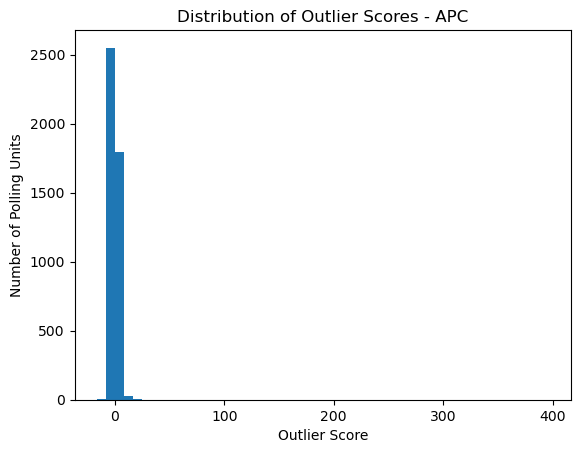

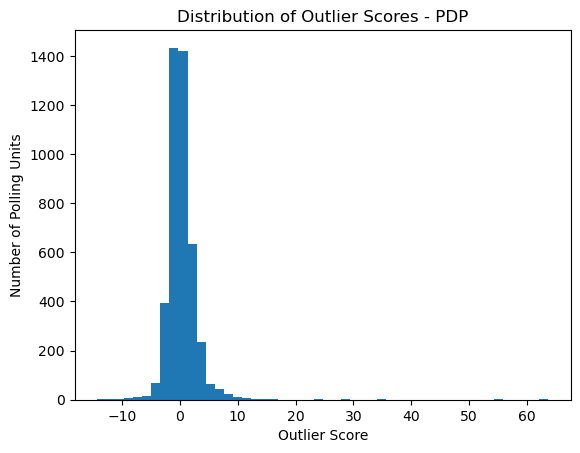

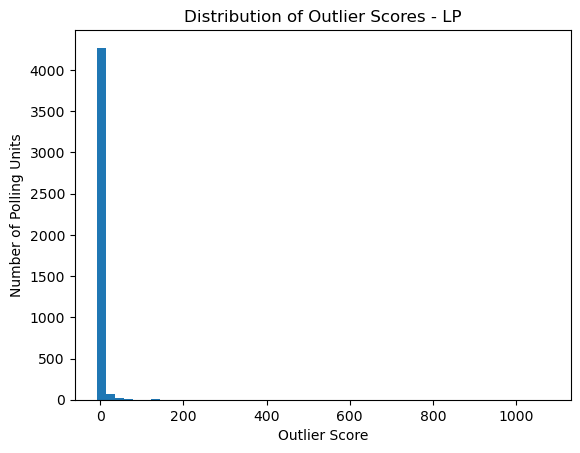

In [9]:
# STEP 7: Visual Summary
# --------------------------------------------
for p in vote_cols:
    plt.figure()
    plt.hist(df[f'{p}_outlier_score'].dropna(), bins=50)
    plt.title(f'Distribution of Outlier Scores - {p}')
    plt.xlabel('Outlier Score')
    plt.ylabel('Number of Polling Units')
    plt.savefig(f'{p}_outlier_hist.png')

print("Histograms saved for all parties.")

In [10]:

# --------------------------------------------
# STEP 8: Console Summary
# --------------------------------------------
print("\n==== SUMMARY ====")
print("Dataset with coordinates & scores -> NIGER_with_outlier_scores.csv")
print("Excel report -> NIGER_outlier_report.xlsx")
print("Map -> NIGER_outlier_map.html")
print("Histograms -> [party]_outlier_hist.png")
print("You can now use these outputs in your written report.")



==== SUMMARY ====
Dataset with coordinates & scores -> NIGER_with_outlier_scores.csv
Excel report -> NIGER_outlier_report.xlsx
Map -> NIGER_outlier_map.html
Histograms -> [party]_outlier_hist.png
You can now use these outputs in your written report.
